In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os, h5py, time, psutil

import numpy as np
import healpy as hp
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm, trange
from sklearn.neighbors import BallTree

# from deepsphere.utils import split_sparse_dense_matmul
from deep_lss.utils import layers

from msfm.grid_pipeline import GridPipeline
from msfm.utils import scales, files

23-11-03 06:43:34   imports.py INF   Setting up healpy to run on 256 CPUs 
23-11-03 06:43:34   imports.py INF   Setting up healpy to run on 256 CPUs 


# example map

In [3]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/tfrecords/grid/DESy3_grid_000.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml"
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

grid_pipe = GridPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False
)

dv_pix = grid_pipe.data_vec_pix
n_dv_pix = len(dv_pix)

n_side = 512
n_pix = hp.nside2npix(n_side)
n_noise = 3

n_channels = grid_pipe.n_z_metacal + grid_pipe.n_z_maglim
n_z_metacal = grid_pipe.n_z_metacal

mask_dict = files.get_tomo_dv_masks(conf)
mask = tf.concat([mask_dict["metacal"], tf.tile(mask_dict["maglim"], (1, 4))], axis=1)

batch_size = 52

dset = grid_pipe.get_dset(
        tfr_pattern=tfr_pattern,
        n_noise=n_noise,
        local_batch_size=batch_size,
        n_readers=1,
        n_prefetch=0,
)

for dv, cosmo, index in dset.take(1):
    pass

print(dv.shape)

23-11-03 06:43:34     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-03 06:43:34     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-03 06:43:36     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-11-03 06:43:36 grid_pipelin INF   Interleaving with n_readers = 1 
23-11-03 06:43:37 grid_pipelin INF   Batching into 52 elements locally 
23-11-03 06:43:37 grid_pipelin WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_conve

In [4]:
smoothing_layer = layers.HealpySmoothingLayer(
    n_side=n_side, 
    indices=dv_pix,
    mask=mask,
    fwhm=[22.1, 15.1, 11.2, 9.4, 65.1, 44.5, 34.1, 28.5],
    # sigma=[9.78, 6.91, 5.65, 3.99, 27.66, 19.14, 14.94, 12.62],
    # sigma=10,
    # per_channel_repetitions=[6, 3, 2, 1, 48, 23, 14, 10],
    n_sigma_support=3,
    data_path="/pscratch/sd/a/athomsen/debug/smoothing_kernel",
)

actual_fwhm = smoothing_layer.fwhm_arcmin * np.sqrt(smoothing_layer.per_channel_repetitions)

23-11-03 06:43:44    layers.py INF   Using the per channel repetitions [ 6  3  2  1 48 23 14 10] 
23-11-03 06:43:44    layers.py INF   Using the per channel smoothing scales sigma = [ 9.8  6.9  5.6  4.  27.7 19.1 14.9 12.6] arcmin, fwhm = [23.  16.3 13.3  9.4 65.1 45.1 35.2 29.7] arcmin 
23-11-03 06:43:44    layers.py INF   Successfully loaded sparse kernel indices and values from /pscratch/sd/a/athomsen/debug/smoothing_kernel 
23-11-03 06:43:44    layers.py INF   Successfully created the sparse kernel tensor 


In [5]:
# trace the function once
tf_smooth = smoothing_layer(dv)

23-11-03 06:43:45    layers.py INF   Successfully built the layer 


In [6]:
%%time
tf_smooth = smoothing_layer(dv)

CPU times: user 4.43 ms, sys: 572 µs, total: 5 ms
Wall time: 4.43 ms


# plotting

In [7]:
i_batch = 0
i_channel = 4

### healpy

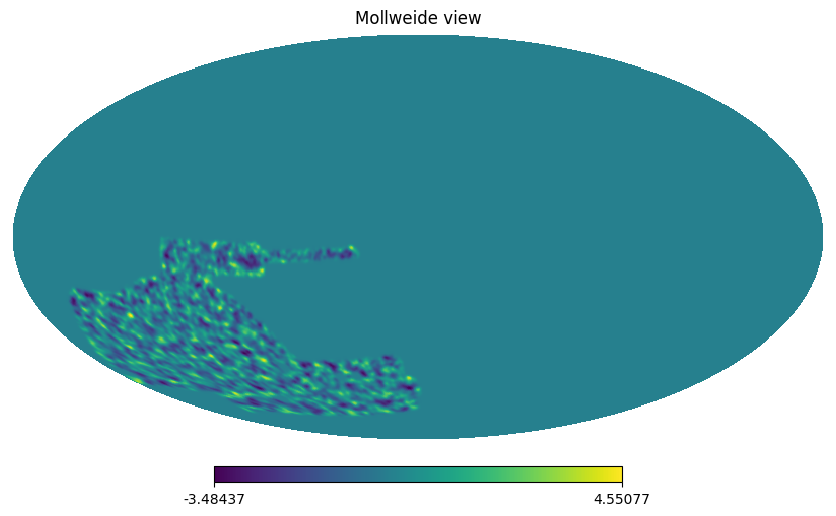

In [8]:
hp_maps = np.zeros((n_pix, n_channels))
hp_maps[dv_pix] = dv[i_batch]
hp_maps, _ = scales.map_to_smoothed_map(hp_maps, n_side, l_min=[0]*8, theta_fwhm=list(actual_fwhm), arcmin=True, nest=True)

hp_gnoms = []
for i in range(n_channels):
    hp_gnoms.append(hp.gnomview(hp_maps[...,i], rot=(90, -30, 0), return_projected_map=True, no_plot=True, nest=True))

hp_gnoms = np.array(hp_gnoms)
hp_gnoms = np.ma.masked_where(hp_gnoms==0, hp_gnoms)

hp.mollview(hp_maps[:,i_channel], nest=True)

### tensorflow

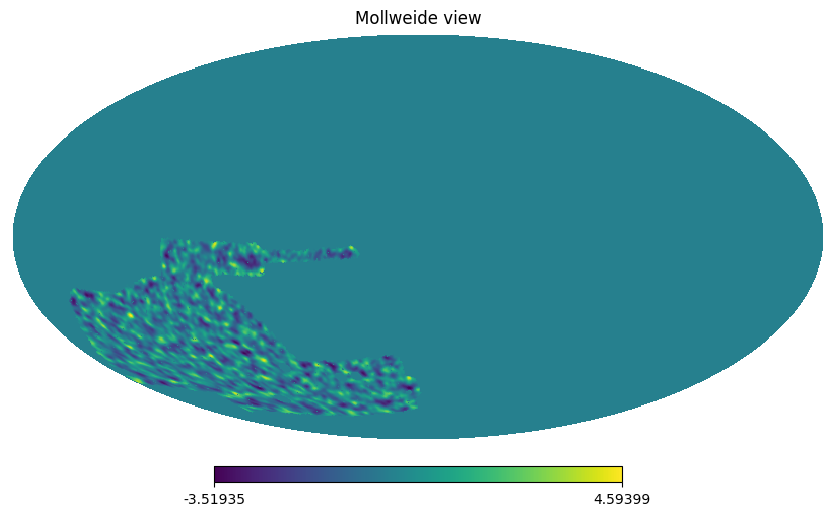

In [9]:
tf_maps = np.zeros((n_pix, n_channels))
tf_maps[dv_pix] = tf_smooth.numpy()[i_batch]

tf_gnoms = []
for i in range(n_channels):
    tf_gnoms.append(hp.gnomview(tf_maps[...,i], rot=(90, -30, 0), return_projected_map=True, no_plot=True, nest=True))
    
tf_gnoms = np.array(tf_gnoms)
tf_gnoms = np.ma.masked_where(tf_gnoms==0, tf_gnoms)

hp.mollview(tf_maps[:,i_channel], nest=True)

### comparison

[Text(0, 0.5, 'difference')]

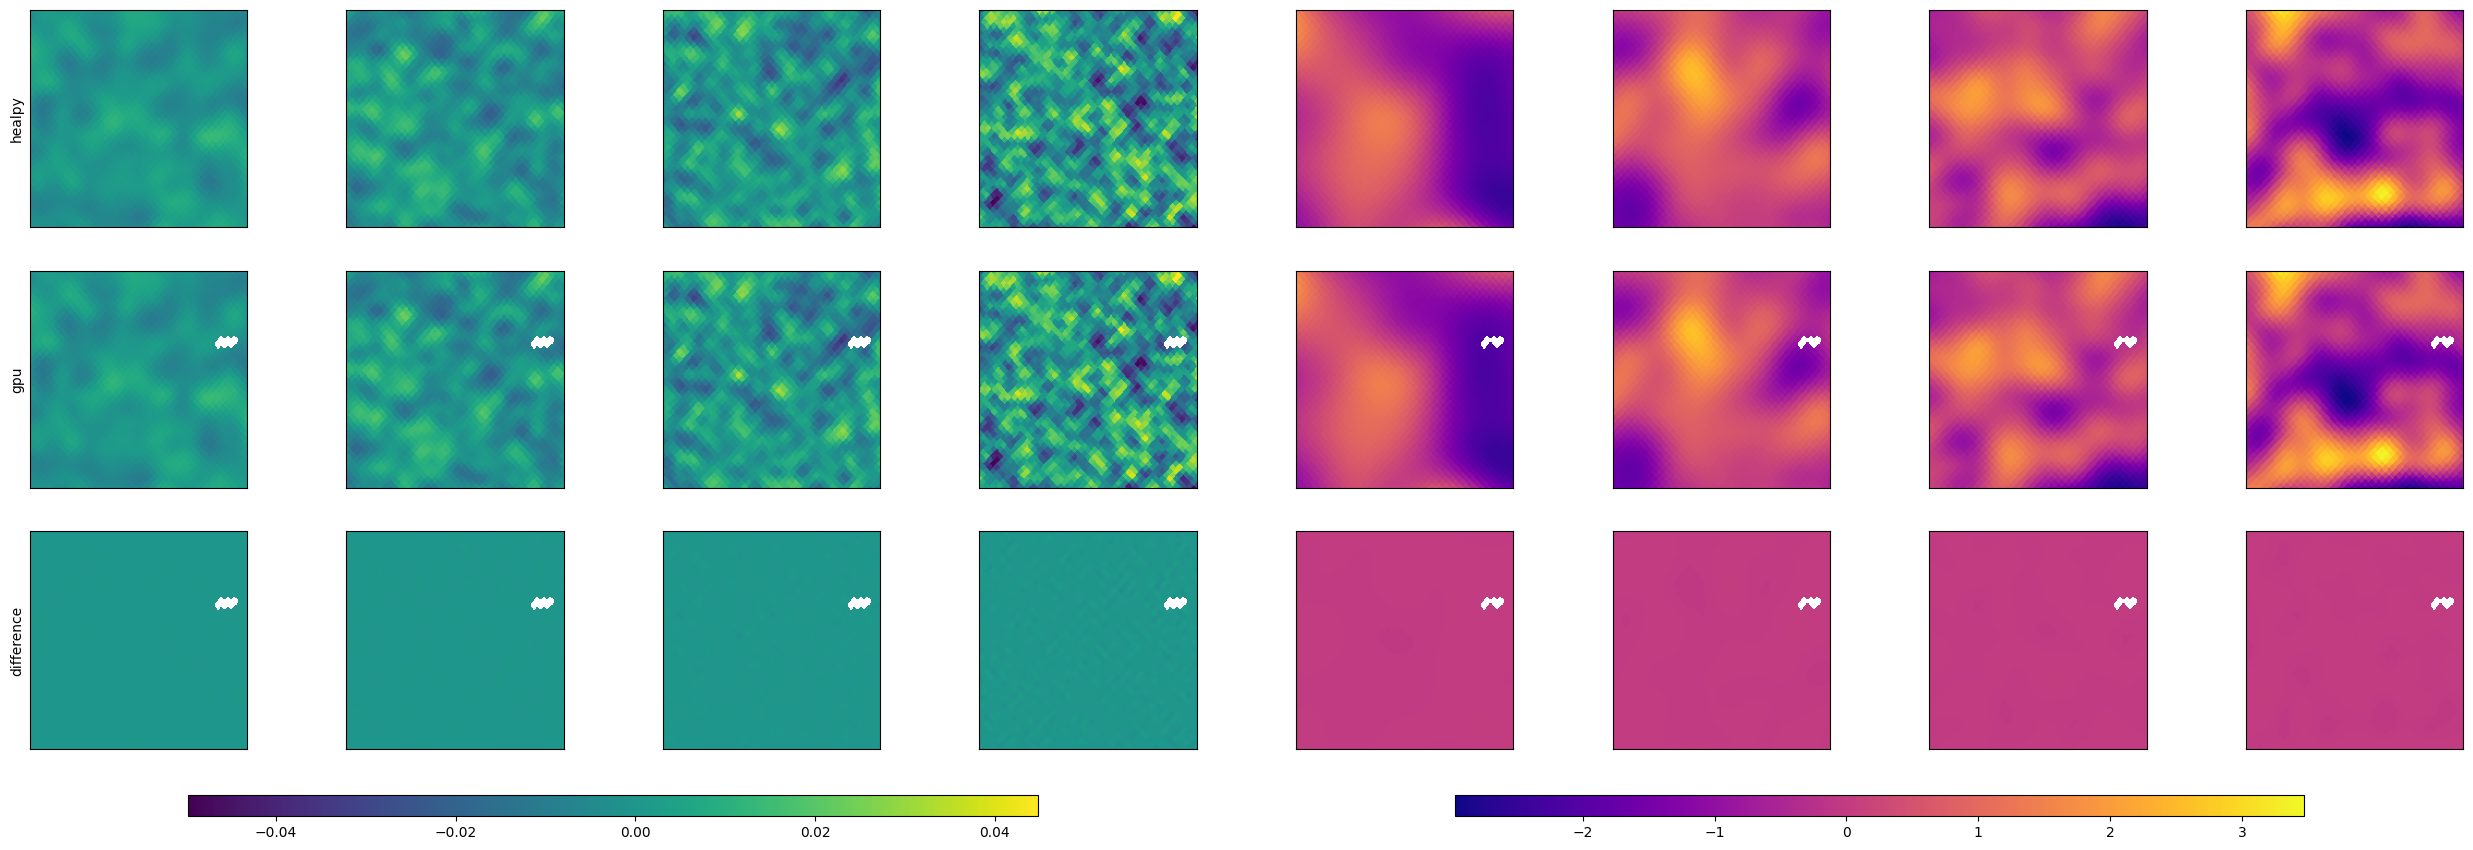

In [10]:
wl_min = tf_gnoms[:n_z_metacal].min()
wl_max = tf_gnoms[:n_z_metacal].max()

gc_min = tf_gnoms[n_z_metacal:].min()
gc_max = tf_gnoms[n_z_metacal:].max()

fig, ax = plt.subplots(figsize=(4*n_channels, 4*3), nrows=3, ncols=n_channels)

for i in range(n_channels):
    # lensing
    if i < n_z_metacal:
        vmin = wl_min
        vmax = wl_max
        cmap = "viridis"

    # clustering
    else:
        vmin = gc_min
        vmax = gc_max
        cmap = "plasma"

    im = ax[0,i].imshow(hp_gnoms[i], vmin=vmin, vmax=vmax, cmap=cmap)
    im = ax[1,i].imshow(tf_gnoms[i], vmin=vmin, vmax=vmax, cmap=cmap)
    
    diff = hp_gnoms[i] - tf_gnoms[i]
    im = ax[2,i].imshow(diff, vmin=vmin, vmax=vmax, cmap=cmap)
    
    # cosmetics
    for j in range(3):
        ax[j, i].set_xticks([])
        ax[j, i].set_yticks([])
        ax[j, i].set_aspect("equal")
        
    if i == 0:
        fig.colorbar(im, ax=ax[:,:n_z_metacal], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)
    if i == 4:
        fig.colorbar(im, ax=ax[:,n_z_metacal:], orientation="horizontal", shrink=0.7, aspect=40, pad=0.05)

        
ax[0,0].set(ylabel="healpy")
ax[1,0].set(ylabel="gpu")
ax[2,0].set(ylabel="difference")
